# Histogram Gradient Boosting - Heart Disease

Explores a tuned Histogram Gradient Boosting classifier on the cleaned splits.

**Method.** Hyperparameters are tuned with stratified 5-fold `GridSearchCV` on the
**training** set; the tuned model is evaluated on the **validation** set. The
**test** set is deliberately left untouched here - it is reserved for the final
cross-model comparison notebook, so the hold-out is spent only once.

`HistGradientBoostingClassifier` is sklearn's fast boosting implementation (the
stand-in for XGBoost in this project): continuous features are binned into
histograms before split finding, which makes each boosting iteration much
cheaper. Like the other tree models it is invariant to monotonic rescaling -
no scaler is added to the pipeline.

In [1]:
import sys
from pathlib import Path

# Make the scripts/ helpers importable from notebooks/.
sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, f1_score, accuracy_score,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay,
)

from dataset import load_splits, get_xy
from train_models import build_pipeline, MODELS, CV

MODEL_NAME = "hist_gradient_boosting"

## Load data

In [2]:
train, val, test = load_splits()
X_train, y_train = get_xy(train)
X_val, y_val = get_xy(val)

print(f"train {X_train.shape}  val {X_val.shape}  (test held back)")
print(f"train disease rate {y_train.mean():.3f}  val {y_val.mean():.3f}")

train (552, 15)  val (184, 15)  (test held back)
train disease rate 0.553  val 0.554


## Tune hyperparameters (train, 5-fold CV)

The estimator and grid come straight from the `MODELS` registry in
`train_models.py`, so the notebook and the batch script stay in sync.

In [3]:
cfg = MODELS[MODEL_NAME]
pipe = build_pipeline(cfg["estimator"], cfg["needs_scaling"], list(X_train.columns))
search = GridSearchCV(pipe, cfg["grid"], cv=CV, scoring="roc_auc", n_jobs=-1)
search.fit(X_train, y_train)

best = search.best_estimator_
print("best params:", search.best_params_)
print(f"cv roc-auc: {search.best_score_:.3f}")

best params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__max_iter': 300}
cv roc-auc: 0.850


## Validation metrics

In [4]:
proba = best.predict_proba(X_val)[:, 1]
pred = best.predict(X_val)

metrics = {
    "roc_auc": roc_auc_score(y_val, proba),
    "recall": recall_score(y_val, pred),
    "precision": precision_score(y_val, pred),
    "f1": f1_score(y_val, pred),
    "accuracy": accuracy_score(y_val, pred),
}
pd.Series(metrics, name=MODEL_NAME).round(3)

roc_auc      0.852
recall       0.873
precision    0.754
f1           0.809
accuracy     0.772
Name: hist_gradient_boosting, dtype: float64

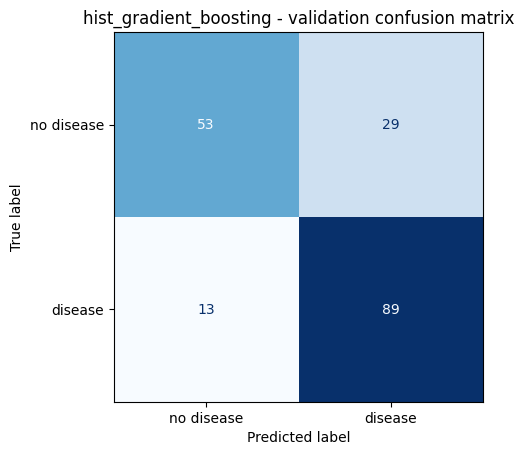

In [5]:
ConfusionMatrixDisplay(
    confusion_matrix(y_val, pred), display_labels=["no disease", "disease"]
).plot(cmap="Blues", colorbar=False)
plt.title(f"{MODEL_NAME} - validation confusion matrix")
plt.show()

## Hyperparameter comparison

`learning_rate` and `max_iter` trade off against each other (more, smaller
steps vs fewer, larger ones), while `max_depth` caps how much interaction each
tree can capture (`None` leaves depth unconstrained and relies on the default
leaf limit). The full grid is small enough to show every configuration.

In [6]:
cv_results = pd.DataFrame(search.cv_results_)
param_cols = ["param_model__learning_rate", "param_model__max_iter", "param_model__max_depth"]

hgb_grid = cv_results[param_cols + ["mean_test_score", "std_test_score"]].copy()
hgb_grid = hgb_grid.rename(columns={
    "param_model__learning_rate": "learning_rate",
    "param_model__max_iter": "max_iter",
    "param_model__max_depth": "max_depth",
    "mean_test_score": "cv_roc_auc",
    "std_test_score": "cv_std",
})
hgb_grid.sort_values("cv_roc_auc", ascending=False).round(3)

,learning_rate,max_iter,max_depth,cv_roc_auc,cv_std
3,0.01,300,3,0.850,0.041
5,0.01,300,5,0.848,0.045
1,0.01,300,None,0.845,0.045
8,0.10,100,3,0.842,0.038
6,0.10,100,None,0.836,0.040
10,0.10,100,5,0.834,0.039
2,0.01,100,3,0.833,0.035
4,0.01,100,5,0.833,0.042
0,0.01,100,None,0.832,0.042
7,0.10,300,None,0.831,0.039


## Staged performance

Boosting adds one tree per iteration, so the tuned model can be scored after
every iteration with `staged_predict_proba`. Training ROC-AUC climbs steadily
as the ensemble memorizes the training set; the validation curve shows where
the extra iterations stop paying for themselves. (Built-in early stopping is
off here - the `"auto"` default only activates above 10,000 samples - so all
`max_iter` iterations run.)

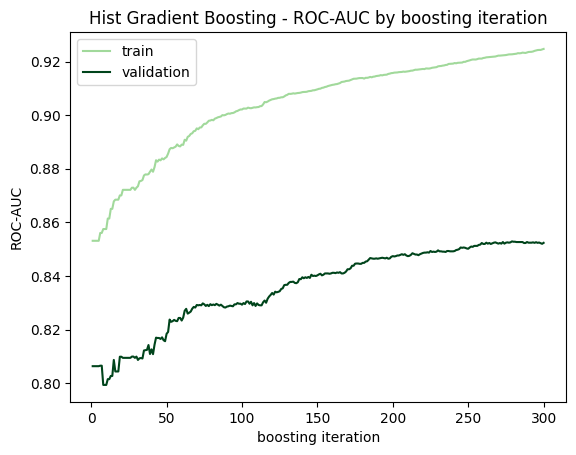

In [7]:
hgb = best.named_steps["model"]

stage_auc_train = [roc_auc_score(y_train, p[:, 1]) for p in hgb.staged_predict_proba(X_train)]
stage_auc_val = [roc_auc_score(y_val, p[:, 1]) for p in hgb.staged_predict_proba(X_val)]
stages = range(1, len(stage_auc_val) + 1)

plt.plot(stages, stage_auc_train, color="#a1d99b", label="train")
plt.plot(stages, stage_auc_val, color="#00441b", label="validation")
plt.xlabel("boosting iteration")
plt.ylabel("ROC-AUC")
plt.title("Hist Gradient Boosting - ROC-AUC by boosting iteration")
plt.legend()
plt.show()

## Permutation importance

Unlike the other tree models, `HistGradientBoostingClassifier` exposes no
impurity-based `feature_importances_`, so features are ranked by **permutation
importance** instead: each column of the validation set is shuffled and the
drop in ROC-AUC is recorded (mean over repeats). This measures what the fitted
model actually relies on, and unlike impurity importance it is not biased
toward continuous features with many split points.

Caveat: ~22% of `chol` is iteratively imputed with low-variance synthetic
values (see PROJECT.md), so read its importance with that in mind.

In [8]:
perm = permutation_importance(
    best, X_val, y_val, scoring="roc_auc", n_repeats=25, random_state=42, n_jobs=-1
)
importance = pd.Series(perm.importances_mean, index=X_val.columns)
importance.sort_values(ascending=False).round(3)

cp_4         0.047
oldpeak      0.023
sex          0.018
thalach      0.017
cp_2         0.015
chol         0.015
age          0.014
exang        0.010
trestbps     0.001
restecg_1    0.001
restecg_2    0.000
cp_1         0.000
restecg_0   -0.000
cp_3        -0.000
fbs         -0.001
dtype: float64

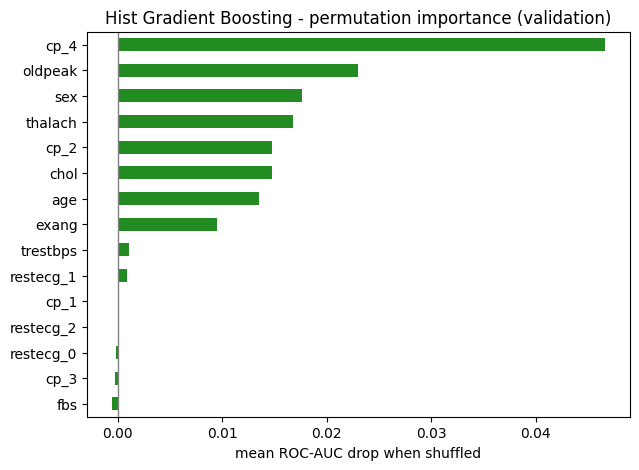

In [9]:
importance.sort_values().plot(kind="barh", color="forestgreen", figsize=(7, 5))
plt.axvline(0, color="gray", lw=1)
plt.xlabel("mean ROC-AUC drop when shuffled")
plt.title("Hist Gradient Boosting - permutation importance (validation)")
plt.show()

## ROC curve (validation)

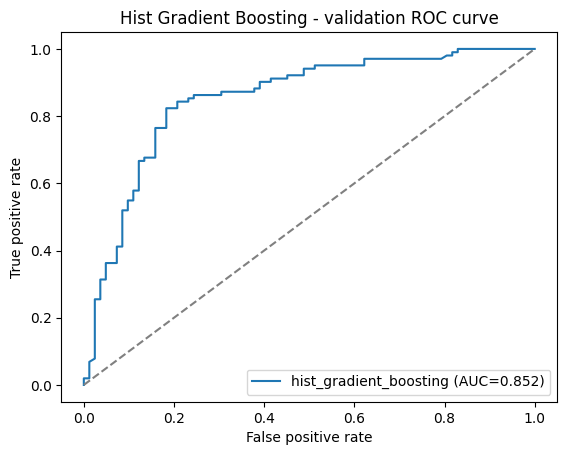

In [10]:
fpr, tpr, _ = roc_curve(y_val, proba)
plt.plot(fpr, tpr, label=f"{MODEL_NAME} (AUC={metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], ls="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Hist Gradient Boosting - validation ROC curve")
plt.legend()
plt.show()

## Notes

- Test set intentionally not touched - see the comparison notebook for the
  single final test evaluation of the selected model.
- The staged curve evaluates intermediate ensembles of the already-tuned
  model; it is a diagnostic, not a second tuning pass.
- Permutation importance is computed on the validation set, so it reflects
  generalization rather than training-set fit; slightly negative values just
  mean shuffling that feature changed nothing beyond noise.
- This notebook is Hist Gradient Boosting specific. To explore another model,
  start from the shared template and swap in a model-appropriate diagnostic.